In [ ]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# 2. LOAD DATA

df = pd.read_csv("/content/survey.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
# EDA

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Statistical Summary ---")
print(df.describe(include="all"))


--- Missing Values ---
Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

--- Data Types ---
Timestamp                

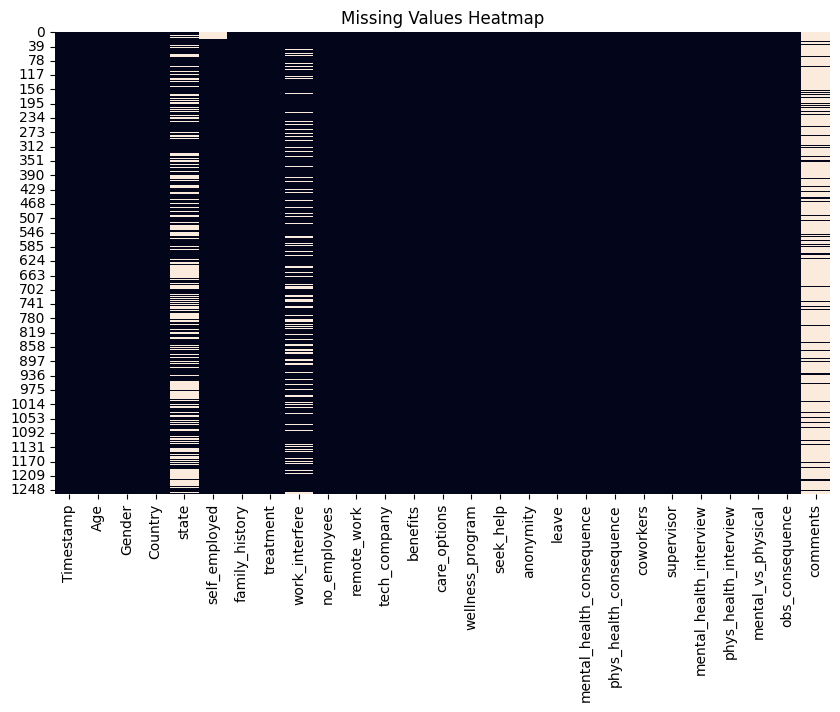

In [ ]:
# EDA Visualization(Missing Values Heatmap)

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

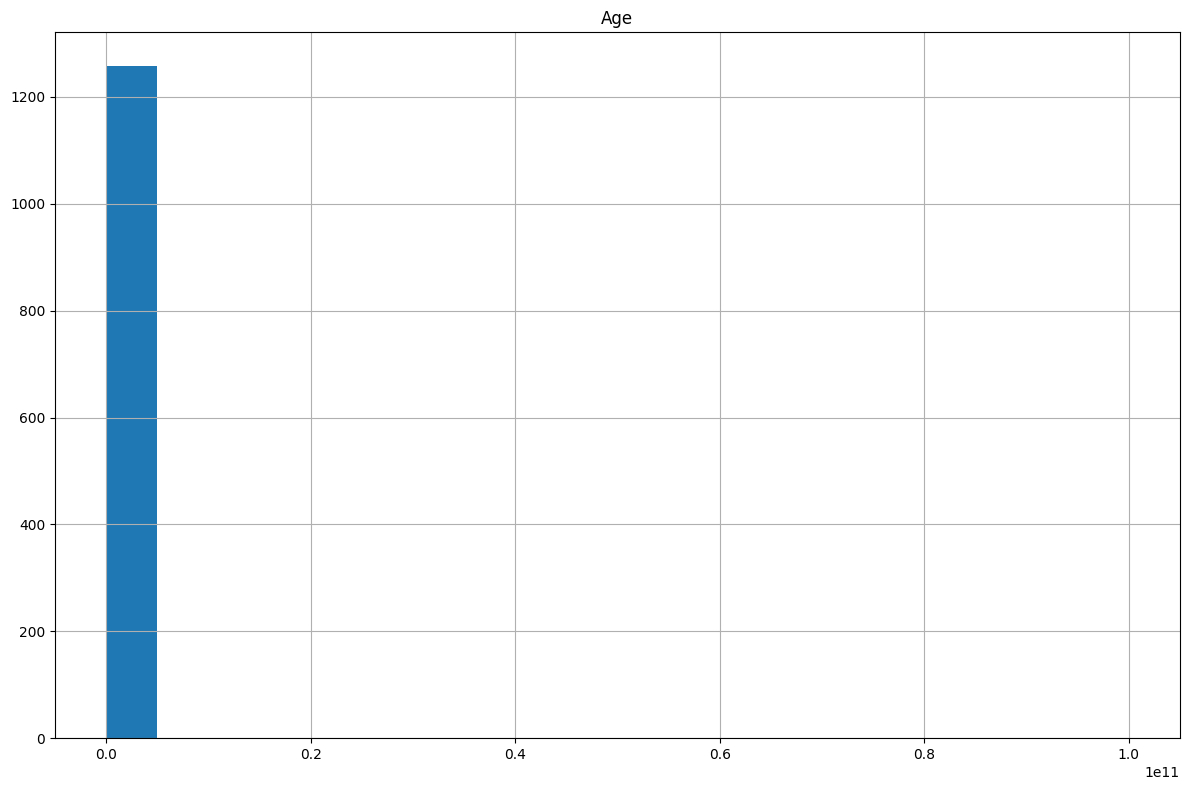

In [ ]:
# Distribution of Numerical Columns

df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

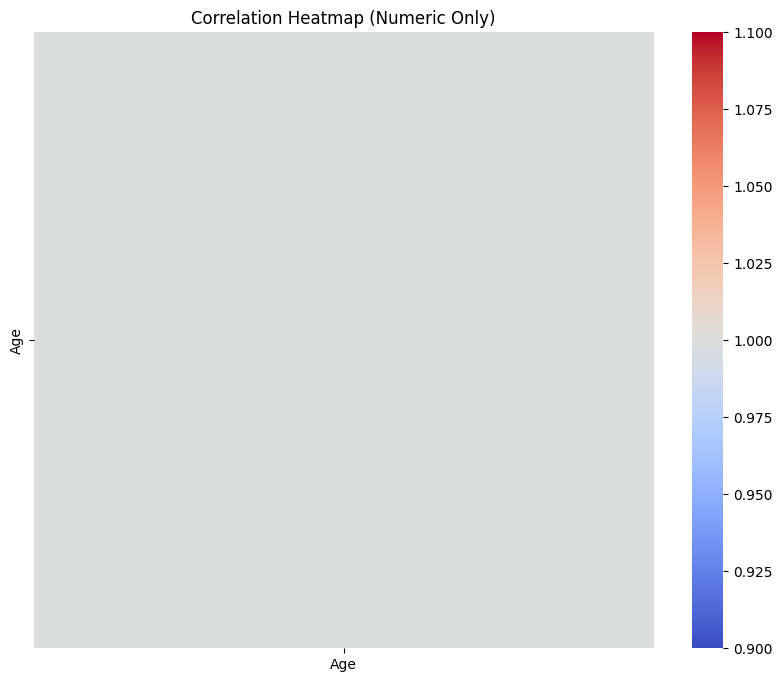

In [ ]:
# Correlation Heatmap (numeric only)

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Only)")
plt.show()

In [ ]:
# Data Preprocesssing for Cluster

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

In [ ]:
# PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame({
    'PC1': pca_data[:, 0],
    'PC2': pca_data[:, 1]
})

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.00375797 0.00339631]


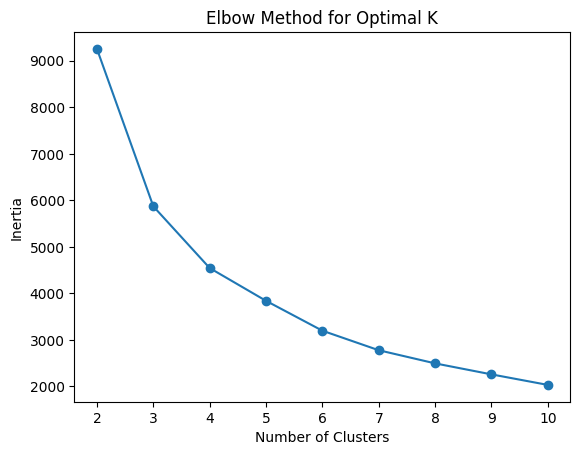

In [ ]:
# Elbow Method

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(pca_data)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
# Silhouette Score test

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    print(f"K={k}, Silhouette Score = {score}")

K=2, Silhouette Score = 0.33509435169780843
K=3, Silhouette Score = 0.3654317449809572
K=4, Silhouette Score = 0.3635694931450125
K=5, Silhouette Score = 0.33419430223975544
K=6, Silhouette Score = 0.34598277430327834
K=7, Silhouette Score = 0.34007935694279245
K=8, Silhouette Score = 0.3313819497868021
K=9, Silhouette Score = 0.3244425526278444
K=10, Silhouette Score = 0.3289687397714438


In [ ]:
# K-Means Model

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_data)

pca_df["Cluster"] = clusters
df["Cluster"] = clusters

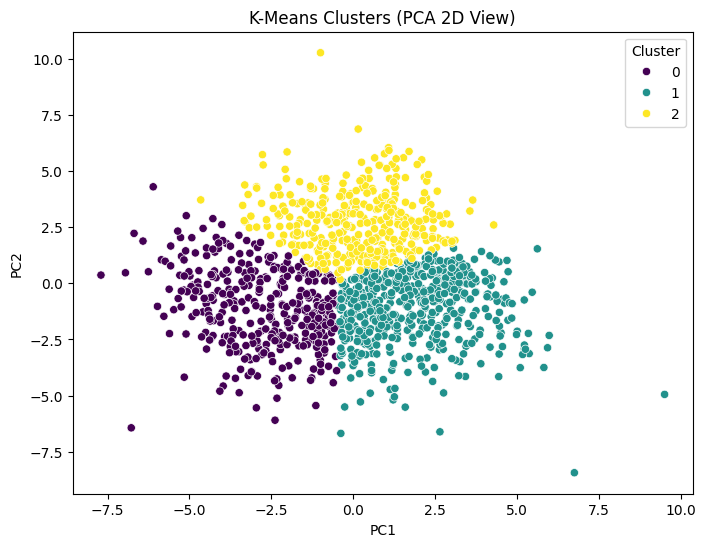

In [ ]:
# Visualize Cluster

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["Cluster"],
    palette="viridis"
)
plt.title("K-Means Clusters (PCA 2D View)")
plt.show()

In [ ]:
# Cluster Profile

# Numeric cluster summary
numeric_df = df.select_dtypes(include=[int, float])
cluster_profile_numeric = numeric_df.groupby(df["Cluster"]).mean()
print("\nNUMERIC CLUSTER PROFILE:")
print(cluster_profile_numeric)

# Categorical cluster summary
categorical_df = df.select_dtypes(include=['object'])
cluster_profile_cat = categorical_df.groupby(df["Cluster"]).agg(lambda x: x.value_counts().index[0])
print("\nCATEGORICAL CLUSTER PROFILE:")
print(cluster_profile_cat)



NUMERIC CLUSTER PROFILE:
                  Age  Cluster
Cluster                       
0        3.322546e+01      0.0
1        1.968504e+08      1.0
2        3.077540e+01      2.0

CATEGORICAL CLUSTER PROFILE:
                   Timestamp Gender        Country state self_employed  \
Cluster                                                                  
0        2014-08-28 09:59:39   Male  United States    CA            No   
1        2014-08-27 15:55:07   Male  United States    CA            No   
2        2015-08-17 09:38:35   Male  United States    TN            No   

        family_history treatment work_interfere    no_employees remote_work  \
Cluster                                                                       
0                   No       Yes      Sometimes  More than 1000          No   
1                   No       Yes      Sometimes          26-100          No   
2                   No        No      Sometimes            6-25          No   

         ...       lea